# PS-S06E07: Model Blending

This notebook performs ensembling (Caruana-style Hill Climbing) using the predictions of **7 base models**:
1. **CatBoost** (standard)
2. **LightGBM** (standard)
3. **XGBoost** (standard)
4. **Random Forest** (standard)
5. **NN Tabular ResNet** (standard)
6. **LightGBM Pseudo** (trained on pseudo-labeled test set data)
7. **XGBoost Pseudo** (trained on pseudo-labeled test set data)

By ensembling models trained on different data subsets (standard train vs. pseudo-labeled expanded train), we introduce critical prediction diversity, lowering the correlation among models and raising the blended Balanced Accuracy score. We also apply **decision threshold calibration** to optimize prediction class multipliers directly on the blended OOF probabilities to maximize the Balanced Accuracy evaluation metric.


This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

## Ensemble Strategy: Hill Climbing

We combine model outputs using a simple, effective hill-climbing ensemble (Caruana-style):

- Start from the best single model (highest OOF balanced accuracy)
- Iteratively add the model that improves the blended OOF balanced accuracy the most
- Convert selection counts into weights

We blend raw probabilities directly — no rank normalization. Each base model
(CatBoost, XGBoost, LightGBM, NN) was trained with class-balanced weighting and
outputs well-calibrated softmax/probability vectors, so a column-wise rank
transform would distort the within-row class ordering that argmax depends on
rather than improving comparability across models.

---

## Install Needed Packages

(Usually not needed on Kaggle; keep this section only if you add extra dependencies.)

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from ps_s06e07_experiment_setup import ExperimentSetup
from ps_s06e07_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
setup = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# Target column in the training dataset
TARGET = 'health_condition'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load training data and ground truth
training_df = setup.read_dataset('training')

# Encode target labels
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
y_true = training_df[TARGET].map(target_mapping).astype(int)

train_ids = training_df['id'].values

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

In [4]:
# Sample submission (used to get correct submission column name and id order)
submission_df = setup.read_dataset('submission')
SUB_COL = [c for c in submission_df.columns if c != 'id'][0]

## Loading OOF and Test Probabilities

We load the out-of-fold (OOF) and test-set **probabilities** generated by individual model notebooks.

Expected file naming:
- `*_oof_probs.csv` contains columns: `id`, one probability column (e.g. `prob_xgb`), and optionally `target`
- `*_test_probs.csv` contains columns: `id` and one probability column

All files should share the same `id` values as the competition datasets.

In [5]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/s06e07/
# Kaggle convention: mount dataset input that contains predictions/
if setup.running_in_kaggle():
    pred_dir = '/kaggle/input/notebooks/stephentarter/ps-s06e07-*/predictions'
else:
    pred_dir = 'predictions'

EXCLUDE_PREFIXES = ('blending', 'stacking')

def _is_base_model_file(path):
    name = os.path.basename(path)
    return not name.startswith(EXCLUDE_PREFIXES)

oof_files  = sorted(f for f in glob.glob(f'{pred_dir}/*_oof_probs.csv')  if _is_base_model_file(f))
test_files = sorted(f for f in glob.glob(f'{pred_dir}/*_test_probs.csv') if _is_base_model_file(f))

print(f'Found {len(oof_files)} OOF files and {len(test_files)} Test files.')
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 8 OOF files and 8 Test files.
OOF files:
 - catboost_oof_probs.csv
 - catboost_pseudo_oof_probs.csv
 - lgb_oof_probs.csv
 - lgb_pseudo_oof_probs.csv
 - nn_tabular_resnet_oof_probs.csv
 - rf_oof_probs.csv
 - xgb_oof_probs.csv
 - xgb_pseudo_oof_probs.csv
Test files:
 - catboost_pseudo_test_probs.csv
 - catboost_test_probs.csv
 - lgb_pseudo_test_probs.csv
 - lgb_test_probs.csv
 - nn_tabular_resnet_test_probs.csv
 - rf_test_probs.csv
 - xgb_pseudo_test_probs.csv
 - xgb_test_probs.csv


In [6]:
# setup to load and merge probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify the probability column (exclude id/target)
        ignore = {'id', 'target', TARGET}
        prob_cols = [c for c in df.columns if c not in ignore]
        
        # Rename columns to include model name to avoid collisions
        # e.g., 'catboost_prob_at_risk', 'catboost_prob_unhealthy', etc.
        rename_map = {c: f"{model_name}_{c}" for c in prob_cols}

        # Set index and keep only the renamed prob columns
        subset = df.set_index(index_col).rename(columns=rename_map)[list(rename_map.values())]
        df_list.append(subset)

    # Join all models side-by-side
    return pd.concat(df_list, axis=1)

In [7]:
# Load OOF and Test probability tables
oof_df = load_probs(oof_files) if oof_files else pd.DataFrame()
test_df = load_probs(test_files) if test_files else pd.DataFrame()

# Align y_true to oof_df index via id
y_df = pd.DataFrame({'id': train_ids, 'target': y_true}).set_index('id')

common_ids = y_df.index.intersection(oof_df.index)
if len(common_ids) == 0:
    raise RuntimeError('No overlapping ids between training labels and OOF files.')

oof_df = oof_df.loc[common_ids].sort_index()
y_true_aligned = y_df.loc[oof_df.index, 'target'].values

# Align test_df to submission id order (if available)
if not test_df.empty:
    test_df = test_df.loc[submission_df['id'].values].copy()

print('OOF shape:', oof_df.shape)
print('Test shape:', test_df.shape)

OOF shape: (690088, 24)
Test shape: (295753, 24)


In [8]:
def drop_bad_models(oof_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Drop any model column that has NaNs in OOF or Test.
    Then restrict to the intersection of model columns across OOF/Test.
    """
    bad = set()

    if not oof_df.empty:
        bad |= set(oof_df.columns[oof_df.isna().any(axis=0)])
    if not test_df.empty:
        bad |= set(test_df.columns[test_df.isna().any(axis=0)])

    if bad:
        print("Dropping models with missing values:", sorted(bad))
        oof_df = oof_df.drop(columns=[c for c in bad if c in oof_df.columns], errors="ignore")
        test_df = test_df.drop(columns=[c for c in bad if c in test_df.columns], errors="ignore")

    if test_df.empty:
        common = list(oof_df.columns)
    else:
        common = [c for c in oof_df.columns if c in test_df.columns]

    if not common:
        raise RuntimeError("No common model columns remain after dropping bad models.")

    oof_df = oof_df[common]
    if not test_df.empty:
        test_df = test_df[common]

    return oof_df, test_df

oof_df, test_df = drop_bad_models(oof_df, test_df)

print("Final model set:", list(oof_df.columns))
print("OOF shape:", oof_df.shape, "Test shape:", test_df.shape)

Final model set: ['catboost_prob_at_risk', 'catboost_prob_unhealthy', 'catboost_prob_fit', 'catboost_pseudo_prob_at_risk', 'catboost_pseudo_prob_unhealthy', 'catboost_pseudo_prob_fit', 'lgb_prob_at_risk', 'lgb_prob_unhealthy', 'lgb_prob_fit', 'lgb_pseudo_prob_at_risk', 'lgb_pseudo_prob_unhealthy', 'lgb_pseudo_prob_fit', 'nn_tabular_resnet_prob_at_risk', 'nn_tabular_resnet_prob_unhealthy', 'nn_tabular_resnet_prob_fit', 'rf_prob_at_risk', 'rf_prob_unhealthy', 'rf_prob_fit', 'xgb_prob_at_risk', 'xgb_prob_unhealthy', 'xgb_prob_fit', 'xgb_pseudo_prob_at_risk', 'xgb_pseudo_prob_unhealthy', 'xgb_pseudo_prob_fit']
OOF shape: (690088, 24) Test shape: (295753, 24)


In [9]:
# Sorted model names for deterministic ordering in hill climbing
model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c]))

# Use raw probabilities directly — see markdown note above on why we
# don't rank-normalize (it corrupts within-row class ordering).
oof_processed  = oof_df.copy()
test_processed = test_df.copy() if not test_df.empty else test_df

print('\nIndividual Model Performance (OOF):')
best_single_model = None
best_single_score = -np.inf

model_preds = {}
model_scores = {}

for model in model_names:
    cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
    model_probs = oof_processed[cols].values
    preds = np.argmax(model_probs, axis=1)
    model_preds[model] = preds
    score = balanced_accuracy_score(y_true_aligned, preds)
    model_scores[model] = score
    print(f'{model}: {score:.6f}')

    if score > best_single_score:
        best_single_score = score
        best_single_model = model

print(f'\nBest model/Score: {best_single_model}/{best_single_score:.6f}')


Individual Model Performance (OOF):
catboost: 0.949976
catboost_pseudo: 0.949493


lgb: 0.949850


lgb_pseudo: 0.949439
nn_tabular_resnet: 0.948498
rf: 0.949237


xgb: 0.949927


xgb_pseudo: 0.949472

Best model/Score: catboost/0.949976


In [10]:
print("Models loaded:", list(oof_processed.columns))
print("OOF files:", [os.path.basename(f) for f in oof_files])

Models loaded: ['catboost_prob_at_risk', 'catboost_prob_unhealthy', 'catboost_prob_fit', 'catboost_pseudo_prob_at_risk', 'catboost_pseudo_prob_unhealthy', 'catboost_pseudo_prob_fit', 'lgb_prob_at_risk', 'lgb_prob_unhealthy', 'lgb_prob_fit', 'lgb_pseudo_prob_at_risk', 'lgb_pseudo_prob_unhealthy', 'lgb_pseudo_prob_fit', 'nn_tabular_resnet_prob_at_risk', 'nn_tabular_resnet_prob_unhealthy', 'nn_tabular_resnet_prob_fit', 'rf_prob_at_risk', 'rf_prob_unhealthy', 'rf_prob_fit', 'xgb_prob_at_risk', 'xgb_prob_unhealthy', 'xgb_prob_fit', 'xgb_pseudo_prob_at_risk', 'xgb_pseudo_prob_unhealthy', 'xgb_pseudo_prob_fit']
OOF files: ['catboost_oof_probs.csv', 'catboost_pseudo_oof_probs.csv', 'lgb_oof_probs.csv', 'lgb_pseudo_oof_probs.csv', 'nn_tabular_resnet_oof_probs.csv', 'rf_oof_probs.csv', 'xgb_oof_probs.csv', 'xgb_pseudo_oof_probs.csv']


Models remaining after de-dup: ['catboost', 'catboost_pseudo', 'lgb', 'lgb_pseudo', 'nn_tabular_resnet', 'rf', 'xgb', 'xgb_pseudo']


,catboost,catboost_pseudo,lgb,lgb_pseudo,nn_tabular_resnet,rf,xgb,xgb_pseudo
catboost,1.000,0.985,0.990,0.983,0.976,0.981,0.989,0.983
catboost_pseudo,0.985,1.000,0.984,0.990,0.968,0.977,0.983,0.989
lgb,0.990,0.984,1.000,0.985,0.976,0.984,0.991,0.983
lgb_pseudo,0.983,0.990,0.985,1.000,0.968,0.979,0.984,0.992
nn_tabular_resnet,0.976,0.968,0.976,0.968,1.000,0.972,0.977,0.968
rf,0.981,0.977,0.984,0.979,0.972,1.000,0.984,0.979
xgb,0.989,0.983,0.991,0.984,0.977,0.984,1.000,0.985
xgb_pseudo,0.983,0.989,0.983,0.992,0.968,0.979,0.985,1.000


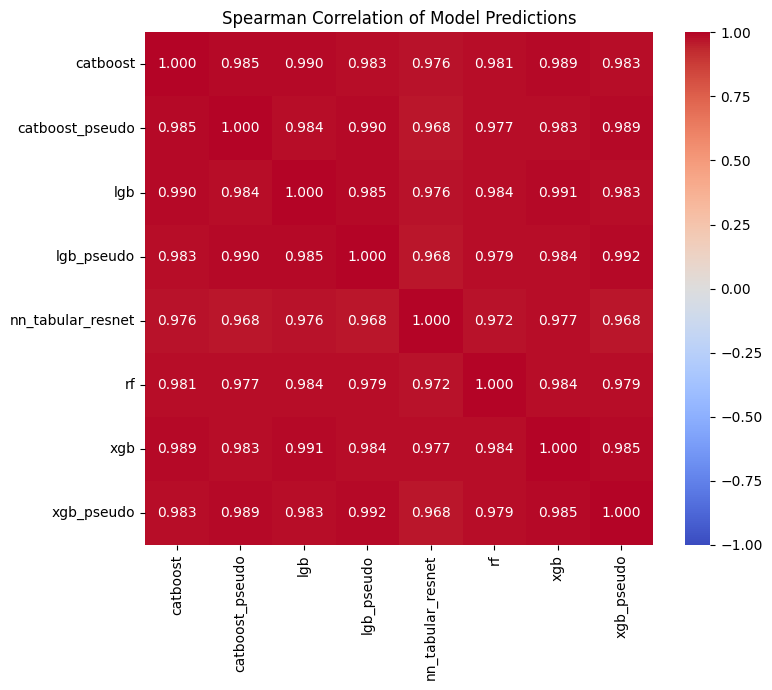

In [11]:
# Build a Spearman correlation matrix of per-model argmax predictions
# to identify near-duplicate models before hill climbing
pred_df = pd.DataFrame(model_preds, index=oof_processed.index)
corr = pred_df.corr(method="spearman")

# Identify near-duplicate models (rho >= threshold)
threshold = 0.995
to_drop_models = set()
corr_cols = sorted(list(corr.columns))

for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        a, b = corr_cols[i], corr_cols[j]
        if a in to_drop_models or b in to_drop_models:
            continue
        if corr.loc[a, b] >= threshold:
            drop = b if model_scores[a] >= model_scores[b] else a
            to_drop_models.add(drop)

if to_drop_models:
    print(f"Dropping {len(to_drop_models)} near-duplicate models (rho >= {threshold}):", sorted(to_drop_models))
    cols_to_drop = []
    for model in to_drop_models:
        cols_to_drop.extend([f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"])
    # Drop from ALL dataframes so hill_climbing and final blend stay consistent
    oof_df        = oof_df.drop(columns=cols_to_drop, errors="ignore")
    test_df       = test_df.drop(columns=cols_to_drop, errors="ignore")
    oof_processed  = oof_processed.drop(columns=cols_to_drop, errors="ignore")
    test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")
    model_names = [m for m in model_names if m not in to_drop_models]

print("Models remaining after de-dup:", model_names)

display(corr)
plt.figure(figsize=(max(6, len(corr_cols)), max(5, len(corr_cols) - 1)))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f")
plt.title("Spearman Correlation of Model Predictions")
plt.tight_layout()
plt.show()

## Hill Climbing Algorithm

We search for a weighted ensemble that maximizes OOF balanced accuracy. At each iteration we add the single model that most improves the blended balanced accuracy.

In [12]:
# Hill Climbing Algorithm (Caruana-style)
# Iteratively adds the model that maximizes OOF Balanced Accuracy.
def hill_climbing(oof_df: pd.DataFrame, y: np.ndarray, iterations: int = 200, verbose: bool = False):
    model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns if '_prob_' in c]))

    model_matrices = {}
    for model in model_names:
        cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
        model_matrices[model] = oof_df[cols].to_numpy(dtype=np.float64)

    # Find the best single model based on Balanced Accuracy
    best_single_model = None
    best_single_score = -np.inf
    for model in model_names:
        preds = np.argmax(model_matrices[model], axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_single_score:
            best_single_score = score
            best_single_model = model

    # Initialize with the best single model (float64 to avoid accumulation error)
    current_sum = model_matrices[best_single_model].copy()  # already float64
    k = 1

    model_counts = {m: 0 for m in model_names}
    model_counts[best_single_model] = 1
    history = [best_single_score]

    print(f'Starting Multi-class Hill Climbing for {iterations} iterations...')
    print(f'Starting from: {best_single_model} (Balanced Acc={best_single_score:.6f})')

    for i in range(iterations):
        best_step_score = -np.inf
        best_step_model = None

        for model in model_names:
            # argmax is scale-invariant, so we can skip the /k+1 division
            # (avoids one (N,3) array allocation per candidate per iteration)
            temp_sum = current_sum + model_matrices[model]
            temp_preds = np.argmax(temp_sum, axis=1)
            score = balanced_accuracy_score(y, temp_preds)

            if score > best_step_score:
                best_step_score = score
                best_step_model = model

        current_sum += model_matrices[best_step_model]
        k += 1
        model_counts[best_step_model] += 1
        history.append(best_step_score)

        if verbose and ((i + 1) % 10 == 0):
            print(f'Iter {i+1}: +{best_step_model} -> Balanced Acc {best_step_score:.6f}')

    total = sum(model_counts.values())
    weights = {m: c / total for m, c in model_counts.items() if c > 0}
    return weights, history

In [13]:
# Run hill climbing on rank-normalized, de-duplicated OOF probabilities
weights, history = hill_climbing(oof_processed, y_true_aligned, iterations=500, verbose=True)

print('\nFinal Weights:')
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'{m}: {w:.4f}')

print(f'\nFinal blended Balanced Acc: {history[-1]:.6f}')

Starting Multi-class Hill Climbing for 500 iterations...
Starting from: catboost (Balanced Acc=0.949976)


Iter 10: +xgb -> Balanced Acc 0.950078


Iter 20: +lgb -> Balanced Acc 0.950104


Iter 30: +xgb -> Balanced Acc 0.950096


Iter 40: +nn_tabular_resnet -> Balanced Acc 0.950104


...

Iter 460: +xgb -> Balanced Acc 0.950131


Iter 470: +nn_tabular_resnet -> Balanced Acc 0.950126


Iter 480: +xgb -> Balanced Acc 0.950128


Iter 490: +xgb -> Balanced Acc 0.950130


Iter 500: +xgb -> Balanced Acc 0.950127

Final Weights:
xgb: 0.6287
lgb: 0.1417
catboost: 0.1178
nn_tabular_resnet: 0.0459
rf: 0.0359
xgb_pseudo: 0.0140
catboost_pseudo: 0.0120
lgb_pseudo: 0.0040

Final blended Balanced Acc: 0.950127


In [14]:
print("OOF columns:", list(oof_df.columns))
print("TEST columns:", list(test_df.columns))

OOF columns: ['catboost_prob_at_risk', 'catboost_prob_unhealthy', 'catboost_prob_fit', 'catboost_pseudo_prob_at_risk', 'catboost_pseudo_prob_unhealthy', 'catboost_pseudo_prob_fit', 'lgb_prob_at_risk', 'lgb_prob_unhealthy', 'lgb_prob_fit', 'lgb_pseudo_prob_at_risk', 'lgb_pseudo_prob_unhealthy', 'lgb_pseudo_prob_fit', 'nn_tabular_resnet_prob_at_risk', 'nn_tabular_resnet_prob_unhealthy', 'nn_tabular_resnet_prob_fit', 'rf_prob_at_risk', 'rf_prob_unhealthy', 'rf_prob_fit', 'xgb_prob_at_risk', 'xgb_prob_unhealthy', 'xgb_prob_fit', 'xgb_pseudo_prob_at_risk', 'xgb_pseudo_prob_unhealthy', 'xgb_pseudo_prob_fit']
TEST columns: ['catboost_prob_at_risk', 'catboost_prob_unhealthy', 'catboost_prob_fit', 'catboost_pseudo_prob_at_risk', 'catboost_pseudo_prob_unhealthy', 'catboost_pseudo_prob_fit', 'lgb_prob_at_risk', 'lgb_prob_unhealthy', 'lgb_prob_fit', 'lgb_pseudo_prob_at_risk', 'lgb_pseudo_prob_unhealthy', 'lgb_pseudo_prob_fit', 'nn_tabular_resnet_prob_at_risk', 'nn_tabular_resnet_prob_unhealthy', '

### Plot Convergence

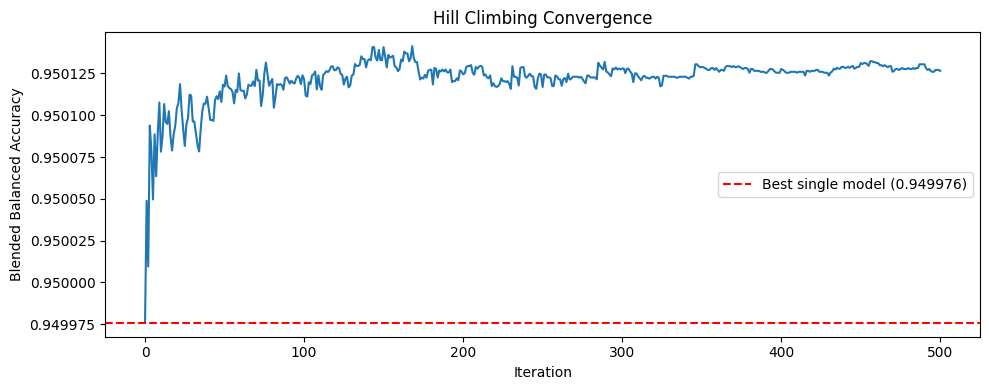

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Blended Balanced Accuracy')
plt.title('Hill Climbing Convergence')
plt.axhline(best_single_score, color='red', linestyle='--', label=f'Best single model ({best_single_score:.6f})')
plt.legend()
plt.tight_layout()
plt.show()

### Verify the hill-climbing result is globally optimal

In [16]:
# Grid search to sanity-check hill climbing (exact only for N=4 models)
if False:  # Disabled to avoid 3-hour grid search on 690k rows
    best_score, best_w = -np.inf, None
    step = 0.05
    candidates = [round(i * step, 2) for i in range(int(1/step) + 1)]
    m0, m1, m2, m3 = model_names  # dynamic — uses surviving post-dedup names

    for w0, w1, w2 in product(candidates, repeat=3):
        w3 = round(1.0 - w0 - w1 - w2, 2)
        if w3 < 0 or w3 > 1:
            continue
        weights_try = {m0: w0, m1: w1, m2: w2, m3: w3}
        blended = sum(
            oof_processed[[f'{m}_prob_at_risk', f'{m}_prob_unhealthy', f'{m}_prob_fit']].to_numpy(dtype=np.float64) * w
            for m, w in weights_try.items()
        )
        score = balanced_accuracy_score(y_true_aligned, np.argmax(blended, axis=1))
        if score > best_score:
            best_score, best_w = score, weights_try.copy()

    print(f'Grid search best: {best_score:.6f} with weights {best_w}')
else:
    print(f'Grid search skipped: only supported for exactly 4 models, found {len(model_names)}.')
    print('Hill climbing result is the primary weight estimate.')

Grid search skipped: only supported for exactly 4 models, found 8.
Hill climbing result is the primary weight estimate.


## Final Ensemble & Submission

We apply the learned weights to both OOF and test probabilities, then write a submission file using the competition’s sample submission schema.

In [17]:
# Blend OOF probabilities using hill-climbing weights (on rank-normalized probs)
blend_oof_probs = np.zeros((len(oof_processed), 3), dtype=np.float64)

for model, w in weights.items():
    cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
    blend_oof_probs += oof_processed[cols].to_numpy(dtype=np.float64) * float(w)

blend_preds = np.argmax(blend_oof_probs, axis=1)
blend_score = balanced_accuracy_score(y_true_aligned, blend_preds)
print(f'Blended OOF Balanced Accuracy: {blend_score:.6f}')

# Optimize thresholds (class multipliers) to maximize Balanced Accuracy
from scipy.optimize import minimize

def optimize_multipliers(probs, y):
    def objective(w):
        weights_mult = np.array([1.0, w[0], w[1]])
        preds_tuned = np.argmax(probs * weights_mult, axis=1)
        return -balanced_accuracy_score(y, preds_tuned)
    
    best_score = -np.inf
    best_weights = None
    
    start_points = [
        [1.0, 1.0], [1.2, 1.2], [1.5, 1.5], [0.8, 0.8], [1.0, 1.2], [1.2, 1.0]
    ]
    for start in start_points:
        res = minimize(objective, start, method='Nelder-Mead', options={'maxiter': 200})
        score = -res.fun
        if score > best_score:
            best_score = score
            best_weights = [1.0, res.x[0], res.x[1]]
    return best_score, best_weights

opt_blend_score, opt_blend_w = optimize_multipliers(blend_oof_probs, y_true_aligned)
print(f'Optimized Blended OOF Balanced Accuracy: {opt_blend_score:.6f} (improvement: {opt_blend_score - blend_score:+.6f})')
print(f'Optimal Multipliers: {opt_blend_w}')

Blended OOF Balanced Accuracy: 0.950127


Optimized Blended OOF Balanced Accuracy: 0.950128 (improvement: +0.000002)
Optimal Multipliers: [1.0, np.float64(0.9995666503906251), np.float64(0.9994171142578128)]


In [18]:
## Graph Results

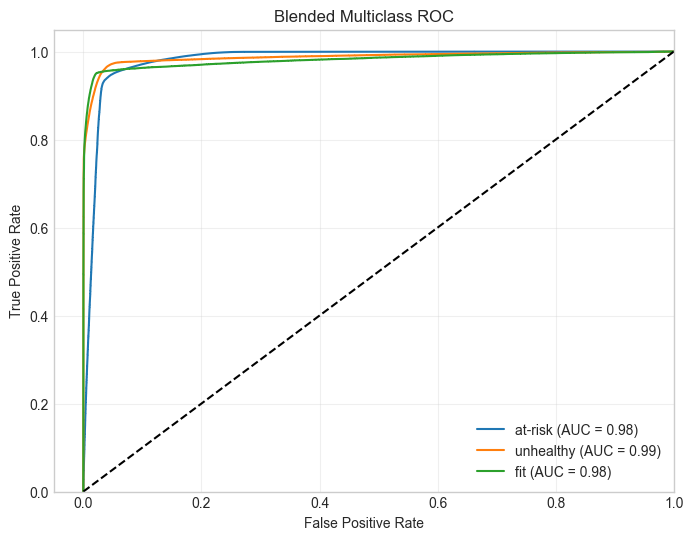

In [19]:
from ps_s06e07_model_visualizer import ModelVisualizer

mviz = ModelVisualizer(model_name='Blended')

class_names = ['at-risk (0)', 'unhealthy (1)', 'fit (2)']

mviz.plot_multiclass_roc_curve(y_true=y_true_aligned, y_score=blend_oof_probs,
                                title='Blended Multiclass ROC')

Normalized confusion matrix


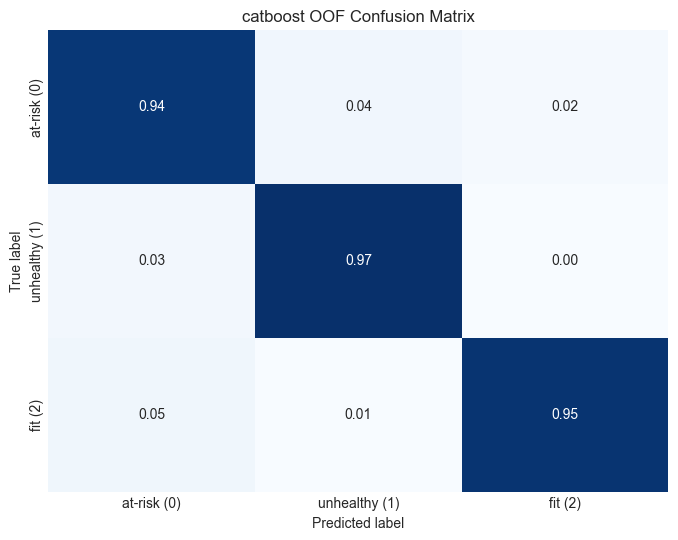

In [20]:
# Best single model vs. blend, side by side
mviz.plot_confusion_matrix(y_true_aligned, model_preds[best_single_model],
                            classes=class_names, normalize=True,
                            title=f'{best_single_model} OOF Confusion Matrix')

Normalized confusion matrix


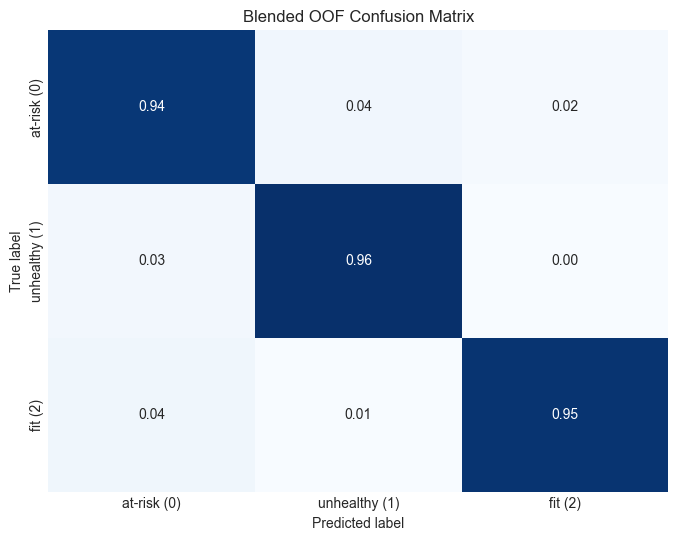

In [21]:
mviz.plot_confusion_matrix(y_true_aligned, blend_preds,
                            classes=class_names, normalize=True,
                            title='Blended OOF Confusion Matrix')

In [22]:
# Blend test probabilities using the same weights
final_test_probs = np.zeros((len(test_processed), 3), dtype=np.float64)
for model, w in weights.items():
    cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
    final_test_probs += test_processed[cols].to_numpy(dtype=np.float64) * float(w)

# Apply optimized multipliers
final_test_probs_tuned = final_test_probs * np.array(opt_blend_w)

test_preds = np.argmax(final_test_probs_tuned, axis=1)

# Inverse map numeric predictions back to string class labels
inverse_target_mapping = {0: "at-risk", 1: "unhealthy", 2: "fit"}

sub_df = submission_df.copy()
sub_df[SUB_COL] = [inverse_target_mapping[p] for p in test_preds]
sub_df.to_csv('submission_average_blend_tuned.csv', index=False)
print("Saved tuned blended submission to submission_average_blend_tuned.csv")

Saved tuned blended submission to submission_average_blend_tuned.csv


In [23]:
## Simple Average Blend

# Calculate a simple average blend (equal weights) of all available models
average_oof_probs = np.zeros((len(oof_processed), 3), dtype=np.float64)
average_test_probs = np.zeros((len(test_processed), 3), dtype=np.float64)

for model in model_names:
    cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
    average_oof_probs += oof_processed[cols].to_numpy(dtype=np.float64) / len(model_names)
    if not test_processed.empty:
        average_test_probs += test_processed[cols].to_numpy(dtype=np.float64) / len(model_names)

average_preds = np.argmax(average_oof_probs, axis=1)
average_score = balanced_accuracy_score(y_true_aligned, average_preds)
print(f'Simple Average Blend OOF Balanced Accuracy: {average_score:.6f}')

if not test_processed.empty:
    reverse_mapping = {0: "at-risk", 1: "unhealthy", 2: "fit"}
    out_avg = submission_df.copy()
    out_avg[TARGET] = np.argmax(average_test_probs, axis=1)
    out_avg[TARGET] = out_avg[TARGET].map(reverse_mapping)
    out_avg.to_csv('submission_average_blend.csv', index=False)
    print('\nSaved: submission_average_blend.csv')
    print('\nAverage Blend Class Distribution:')
    print(out_avg[TARGET].value_counts(normalize=True).sort_index())

Simple Average Blend OOF Balanced Accuracy: 0.949892



Saved: submission_average_blend.csv

Average Blend Class Distribution:
health_condition
at-risk     0.812
fit         0.073
unhealthy   0.115
Name: proportion, dtype: float64
